In [4]:
import os
import logging

os.environ["KAGGLE_ENVS_LOG_LEVEL"] = "ERROR"
logging.getLogger().setLevel(logging.ERROR)

import random
import numpy as np

random.seed(42)
np.random.seed(42)

from kaggle_environments import make
from kaggle_environments.envs.orbit_wars.orbit_wars import Planet
import matplotlib.pyplot as plt
import math
import pandas as pd
from matplotlib.ticker import MaxNLocator
from tqdm import tqdm


In [5]:
env = make("orbit_wars", debug=True)

In [6]:
def fleet_speed(num_ships, max_speed=6.0):
    ratio = math.log(num_ships) / math.log(1000)
    ratio = max(0.0, ratio)
    return 1.0 + (max_speed - 1.0) * (ratio ** 1.5)

def split_planets(obs):
    player = obs["player"]
    planets = obs["planets"]

    my_planets = [p for p in planets if p[1] == player]
    targets = [p for p in planets if p[1] != player]

    return my_planets, targets

def get_nearest_target(mine, targets):
    return min(
        targets,
        key=lambda t: math.hypot(mine[2] - t[2], mine[3] - t[3])
    )

def get_angle(source, target):
    dx = target[2] - source[2]
    dy = target[3] - source[3]
    return math.atan2(dy, dx)

In [7]:
def nearest_agent(obs):
    moves = []

    my_planets, targets = split_planets(obs)

    if not my_planets or not targets:
        return moves

    for mine in my_planets:
        nearest = get_nearest_target(mine, targets)

        ships_needed = nearest[5] + 1

        if mine[5] >= ships_needed:
            angle = get_angle(mine, nearest)
            moves.append([mine[0], angle, ships_needed])

    return moves

In [12]:
def print_game_result(env):
    final_obs = env.steps[-1][0].observation
    player = final_obs.player

    all_players = set()
    for step in env.steps:
        obs = step[0].observation
        for p in obs.planets:
            if p[1] != -1:
                all_players.add(p[1])
        for f in obs.fleets:
            if f[1] != -1:
                all_players.add(f[1])

    all_players = sorted(all_players)

    planets = [Planet(*p) for p in final_obs.planets]
    fleets = final_obs.fleets

    scores = {}

    for pid in all_players:
        planet_ships = sum(p.ships for p in planets if p.owner == pid)
        fleet_ships = sum(f[6] for f in fleets if f[1] == pid)
        scores[pid] = planet_ships + fleet_ships

    ranking = sorted(scores.items(), key=lambda x: x[1], reverse=True)

    my_score = scores.get(player, 0)
    my_rank = [pid for pid, _ in ranking].index(player) + 1

    print("===== Game Result =====")
    print(f"My player ID: {player}")
    print(f"My score: {my_score}")
    print(f"My rank: {my_rank} / {len(all_players)}")

    print("Result:", "WIN" if my_rank == 1 else "LOSE")

    print("\nRanking:")
    for rank, (pid, score) in enumerate(ranking, start=1):
        marker = " <-- me" if pid == player else ""
        print(f"{rank}. Player {pid}: {score}{marker}")
        
def plot_game_state(env):
    steps = []

    my_neutral_capture_steps = []
    my_enemy_capture_steps = []
    enemy_neutral_capture_steps = []
    enemy_enemy_capture_steps = []
    lost_planet_steps = []

    prev_owners = None

    players = set()
    for step_idx in range(len(env.steps)):
        obs = env.steps[step_idx][0].observation
        for p in obs.planets:
            if p[1] != -1:
                players.add(p[1])

    players = sorted(players)
    is_multi = len(players) > 2

    for step_idx in range(1, len(env.steps)):
        obs = env.steps[step_idx][0].observation
        player = obs.player
        planets = [Planet(*p) for p in obs.planets]

        curr_owners = {p.id: p.owner for p in planets}

        my_neutral_captures = 0
        my_enemy_captures = 0
        enemy_neutral_captures = 0
        enemy_enemy_captures = 0
        lost_planets = 0

        if prev_owners is not None:
            for pid, curr_owner in curr_owners.items():
                prev_owner = prev_owners.get(pid)

                if prev_owner is None or prev_owner == curr_owner:
                    continue

                if curr_owner == player and prev_owner == -1:
                    my_neutral_captures += 1

                elif curr_owner == player and prev_owner not in (-1, player):
                    my_enemy_captures += 1

                elif prev_owner == player and curr_owner != player:
                    lost_planets += 1

                elif prev_owner == -1 and curr_owner not in (-1, player):
                    enemy_neutral_captures += 1

                elif (
                    prev_owner not in (-1, player)
                    and curr_owner not in (-1, player)
                    and prev_owner != curr_owner
                ):
                    enemy_enemy_captures += 1

        my_neutral_capture_steps.append(my_neutral_captures)
        my_enemy_capture_steps.append(my_enemy_captures)
        enemy_neutral_capture_steps.append(enemy_neutral_captures)
        enemy_enemy_capture_steps.append(enemy_enemy_captures)
        lost_planet_steps.append(lost_planets)

        prev_owners = curr_owners
        steps.append(step_idx)
        
    print_game_result(env)

    # =========================
    # 2-player plot
    # =========================
    if not is_multi:
        my_planets_list = []
        enemy_planets_list = []
        neutral_planets_list = []
        my_ships_list = []
        enemy_ships_list = []

        for step_idx in range(1, len(env.steps)):
            obs = env.steps[step_idx][0].observation
            player = obs.player
            planets = [Planet(*p) for p in obs.planets]

            my_planets = [p for p in planets if p.owner == player]
            enemy_planets = [p for p in planets if p.owner not in (-1, player)]
            neutral_planets = [p for p in planets if p.owner == -1]

            my_planets_list.append(len(my_planets))
            enemy_planets_list.append(len(enemy_planets))
            neutral_planets_list.append(len(neutral_planets))

            my_ships_list.append(sum(p.ships for p in my_planets))
            enemy_ships_list.append(sum(p.ships for p in enemy_planets))

        fig, ax1 = plt.subplots(figsize=(12, 5))

        line1, = ax1.plot(steps, my_planets_list, label="My planets")
        line2, = ax1.plot(steps, enemy_planets_list, label="Enemy planets")
        line3, = ax1.plot(steps, neutral_planets_list, label="Neutral planets")

        ax1.set_xlabel("Step")
        ax1.set_ylabel("Planet count")
        ax1.yaxis.set_major_locator(MaxNLocator(integer=True))

        ax2 = ax1.twinx()
        line4, = ax2.plot(steps, my_ships_list, linestyle="--", label="My ships")
        line5, = ax2.plot(steps, enemy_ships_list, linestyle="--", label="Enemy ships")
        ax2.set_ylabel("Ships")

        ax3 = ax1.twinx()
        ax3.spines["right"].set_position(("outward", 60))

        bars = []
        bottom = [0] * len(steps)

        bar1 = ax3.bar(
            steps,
            my_neutral_capture_steps,
            bottom=bottom,
            alpha=0.35,
            width=1.0,
            label="My neutral captures",
            color="skyblue"
        )
        bars.append(bar1)
        bottom = [b + v for b, v in zip(bottom, my_neutral_capture_steps)]

        bar2 = ax3.bar(
            steps,
            my_enemy_capture_steps,
            bottom=bottom,
            alpha=0.35,
            width=1.0,
            label="My enemy captures",
            color="green"
        )
        bars.append(bar2)
        bottom = [b + v for b, v in zip(bottom, my_enemy_capture_steps)]

        bar3 = ax3.bar(
            steps,
            enemy_neutral_capture_steps,
            bottom=bottom,
            alpha=0.35,
            width=1.0,
            label="Enemy neutral captures",
            color="orange"
        )
        bars.append(bar3)
        bottom = [b + v for b, v in zip(bottom, enemy_neutral_capture_steps)]

        bar4 = ax3.bar(
            steps,
            lost_planet_steps,
            bottom=bottom,
            alpha=0.45,
            width=1.0,
            label="Lost planets",
            color="red"
        )
        bars.append(bar4)

        max_capture = max(
            [
                n + me + en + l
                for n, me, en, l in zip(
                    my_neutral_capture_steps,
                    my_enemy_capture_steps,
                    enemy_neutral_capture_steps,
                    lost_planet_steps
                )
            ],
            default=0
        )

        ax3.set_ylim(0, max_capture + 1)
        ax3.set_ylabel("Capture events")
        ax3.yaxis.set_major_locator(MaxNLocator(integer=True))

        lines = [line1, line2, line3, line4, line5] + bars
        labels = [l.get_label() for l in lines]
        ax1.legend(lines, labels, loc="upper left")

        plt.title("Game State and Capture Events Over Time")
        plt.show()

    # =========================
    # 4-player plots
    # =========================
    else:
        # 1. Capture Events
        fig, ax = plt.subplots(figsize=(12, 4))

        bottom = [0] * len(steps)

        ax.bar(
            steps,
            my_neutral_capture_steps,
            bottom=bottom,
            color="skyblue",
            alpha=0.4,
            width=1.0,
            label="My neutral captures"
        )
        bottom = [b + v for b, v in zip(bottom, my_neutral_capture_steps)]

        ax.bar(
            steps,
            my_enemy_capture_steps,
            bottom=bottom,
            color="green",
            alpha=0.4,
            width=1.0,
            label="My enemy captures"
        )
        bottom = [b + v for b, v in zip(bottom, my_enemy_capture_steps)]

        ax.bar(
            steps,
            enemy_neutral_capture_steps,
            bottom=bottom,
            color="orange",
            alpha=0.4,
            width=1.0,
            label="Enemy neutral captures"
        )
        bottom = [b + v for b, v in zip(bottom, enemy_neutral_capture_steps)]

        if any(v > 0 for v in enemy_enemy_capture_steps):
            ax.bar(
                steps,
                enemy_enemy_capture_steps,
                bottom=bottom,
                color="purple",
                alpha=0.4,
                width=1.0,
                label="Enemy enemy captures"
            )
            bottom = [b + v for b, v in zip(bottom, enemy_enemy_capture_steps)]

        ax.bar(
            steps,
            lost_planet_steps,
            bottom=bottom,
            color="red",
            alpha=0.5,
            width=1.0,
            label="Lost planets"
        )

        max_capture = max(
            [
                n + me + en + ee + l
                for n, me, en, ee, l in zip(
                    my_neutral_capture_steps,
                    my_enemy_capture_steps,
                    enemy_neutral_capture_steps,
                    enemy_enemy_capture_steps,
                    lost_planet_steps
                )
            ],
            default=0
        )

        ax.set_ylim(0, max_capture + 1)
        ax.yaxis.set_major_locator(MaxNLocator(integer=True))

        ax.set_title("Capture Events Over Time")
        ax.set_xlabel("Step")
        ax.set_ylabel("Capture events")
        ax.legend(loc="upper left")
        plt.show()

        # 2. Planet Count by Player + Neutral
        player_planets = {pid: [] for pid in players}
        neutral_planets_by_step = []

        for step_idx in range(1, len(env.steps)):
            obs = env.steps[step_idx][0].observation
            planets = [Planet(*p) for p in obs.planets]

            neutral_planets_by_step.append(
                len([p for p in planets if p.owner == -1])
            )

            for pid in players:
                owned = [p for p in planets if p.owner == pid]
                player_planets[pid].append(len(owned))

        fig, ax = plt.subplots(figsize=(12, 5))

        for pid in players:
            ax.plot(steps, player_planets[pid], label=f"Player {pid}")

        ax.plot(
            steps,
            neutral_planets_by_step,
            linestyle="--",
            label="Neutral"
        )

        ax.set_title("Planet Count by Player + Neutral")
        ax.set_xlabel("Step")
        ax.set_ylabel("Planet count")
        ax.yaxis.set_major_locator(MaxNLocator(integer=True))
        ax.legend()
        plt.show()

        # 3. Ship Count by Player
        player_ships = {pid: [] for pid in players}

        for step_idx in range(1, len(env.steps)):
            obs = env.steps[step_idx][0].observation
            planets = [Planet(*p) for p in obs.planets]

            for pid in players:
                owned = [p for p in planets if p.owner == pid]
                player_ships[pid].append(sum(p.ships for p in owned))

        fig, ax = plt.subplots(figsize=(12, 5))

        for pid in players:
            ax.plot(
                steps,
                player_ships[pid],
                linestyle="--",
                label=f"Player {pid}"
            )

        ax.set_title("Ship Count by Player")
        ax.set_xlabel("Step")
        ax.set_ylabel("Ships")
        ax.legend()
        
        plt.show()
    

===== Game Result =====
My player ID: 0
My score: 3376
My rank: 1 / 2
Result: WIN

Ranking:
1. Player 0: 3376 <-- me
2. Player 1: 0


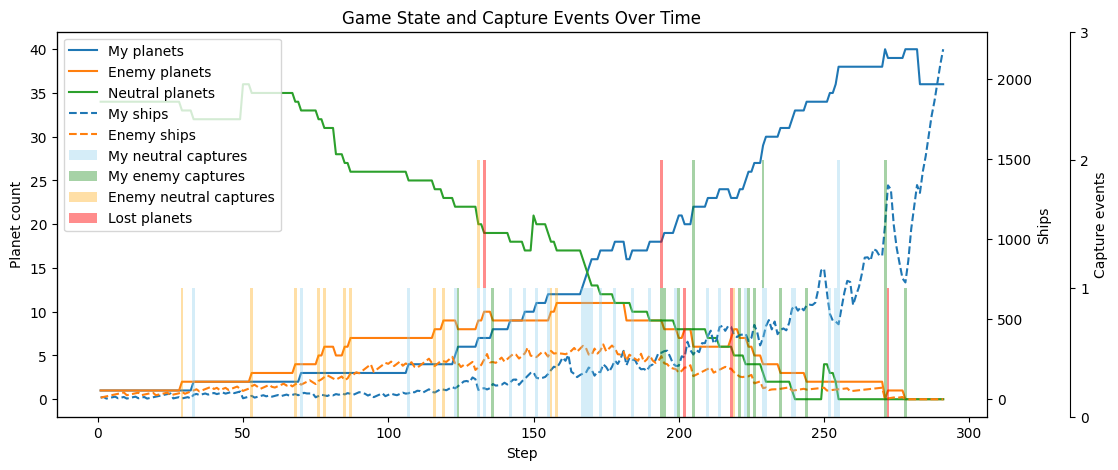

In [13]:
env = make("orbit_wars", debug=True, configuration={"seed": 42})
env.run([nearest_agent, "random"])
plot_game_state(env)

===== Game Result =====
My player ID: 0
My score: 3593
My rank: 1 / 4
Result: WIN

Ranking:
1. Player 0: 3593 <-- me
2. Player 1: 0
3. Player 2: 0
4. Player 3: 0


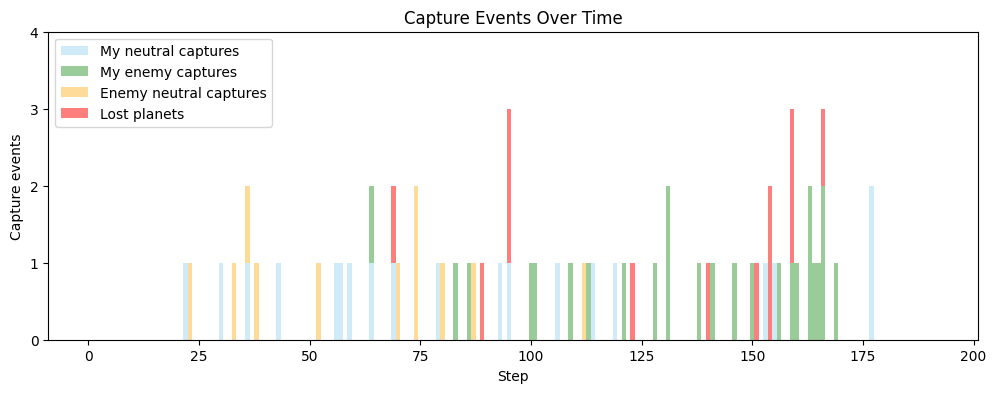

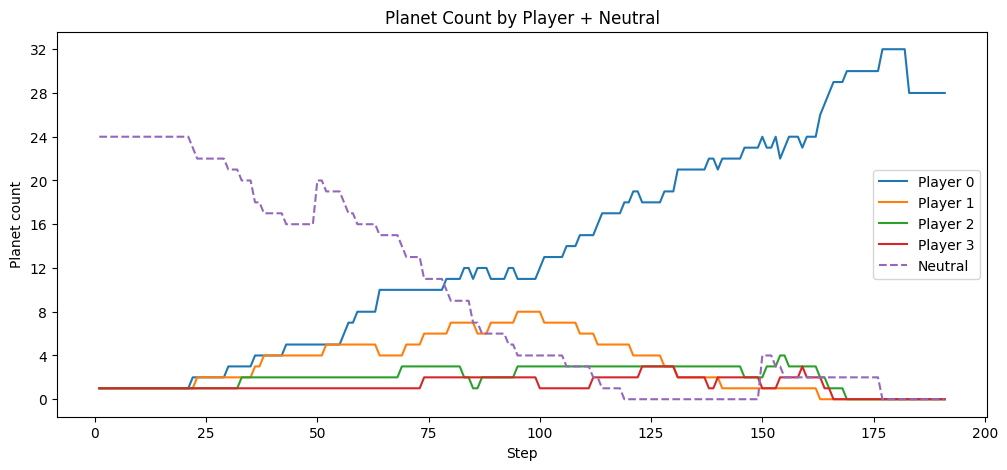

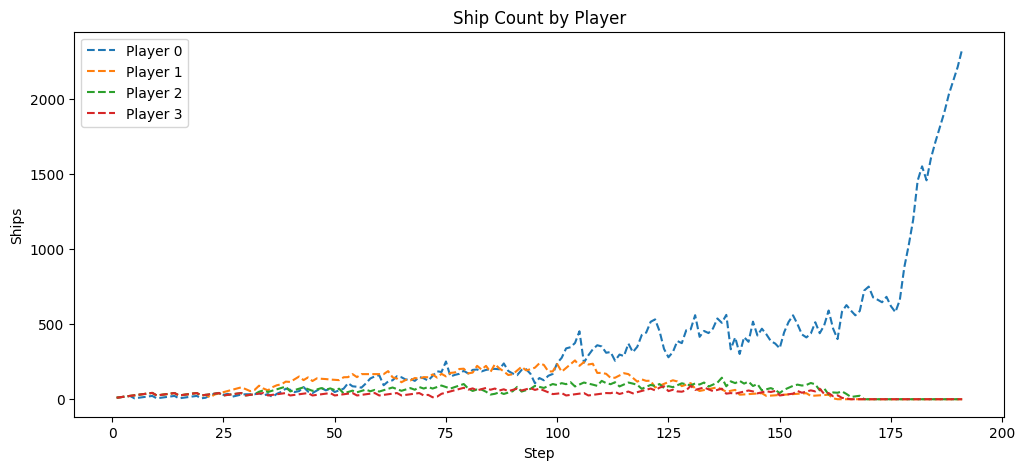

In [14]:
env = make("orbit_wars", debug=True, configuration={"seed": 42})
env.run([nearest_agent, "random","random","random"])
plot_game_state(env)

In [17]:
def get_reserved_targets(
    obs,
    angle_threshold=0.1,
    use_capture_filter=False
):

    planets = obs["planets"]
    fleets = obs["fleets"]
    player = obs["player"]

    reserved_targets = set()

    # Extract only our fleets
    my_fleets = [f for f in fleets if f[1] == player]

    for f in my_fleets:
        fx, fy = f[2], f[3]      # fleet position
        angle = f[4]             # fleet travel direction

        best_planet = None
        best_angle_diff = float("inf")

        # Try to infer which planet this fleet is heading toward
        for p in planets:

            # Skip origin planet (fleet just launched from here)
            if p[0] == f[5]:
                continue

            dx = p[2] - fx
            dy = p[3] - fy

            # Angle from fleet to this planet
            target_angle = math.atan2(dy, dx)

            # Angle difference normalized to [-pi, pi] (wrap-around safe)
            diff = abs(math.atan2(
                math.sin(target_angle - angle),
                math.cos(target_angle - angle)
            ))

            # Keep the closest match in angle space
            if diff < best_angle_diff:
                best_angle_diff = diff
                best_planet = p

        # If no candidate found, skip
        if best_planet is None:
            continue

        # If angle mismatch is too large, ignore (not likely the target)
        if best_angle_diff >= angle_threshold:
            continue

        # Optional: ignore fleets that cannot actually capture the planet
        if use_capture_filter and f[6] <= best_planet[5]:
            continue

        # Mark this planet as already targeted
        reserved_targets.add(best_planet[0])

    return reserved_targets

In [18]:
def in_flight_agent(obs):
    moves = []

    my_planets, targets = split_planets(obs)
    
    # If nothing to act on, do nothing
    if not my_planets or not targets:
        return moves

    reserved_targets = get_reserved_targets(obs)

    for mine in my_planets:

        # Exclude targets that are already being attacked
        available_targets = [
            t for t in targets if t[0] not in reserved_targets
        ]

        # If no valid targets remain, skip this planet
        if not available_targets:
            continue

        nearest = get_nearest_target(mine, available_targets)

        ships_needed = nearest[5] + 1

        # Only launch if we have enough ships
        if mine[5] >= ships_needed:
            angle = get_angle(mine, nearest)
            # Launch fleet
            moves.append([mine[0], angle, ships_needed])
            reserved_targets.add(nearest[0])

    return moves

===== Game Result =====
My player ID: 0
My score: 8381
My rank: 1 / 2
Result: WIN

Ranking:
1. Player 0: 8381 <-- me
2. Player 1: 0


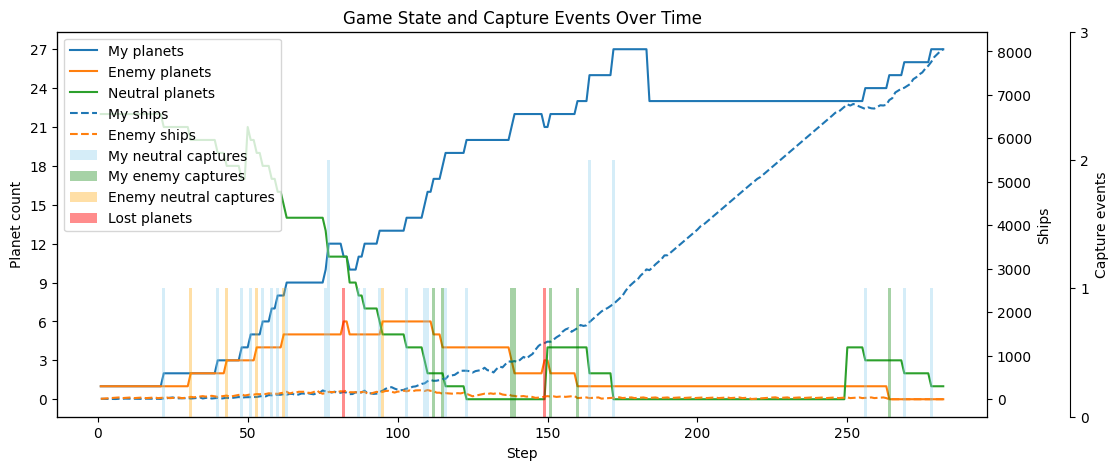

In [19]:
env = make("orbit_wars", debug=True, configuration={"seed": 42})
env.run([in_flight_agent, "random"])

plot_game_state(env)

===== Game Result =====
My player ID: 0
My score: 8639
My rank: 1 / 4
Result: WIN

Ranking:
1. Player 0: 8639 <-- me
2. Player 1: 0
3. Player 2: 0
4. Player 3: 0


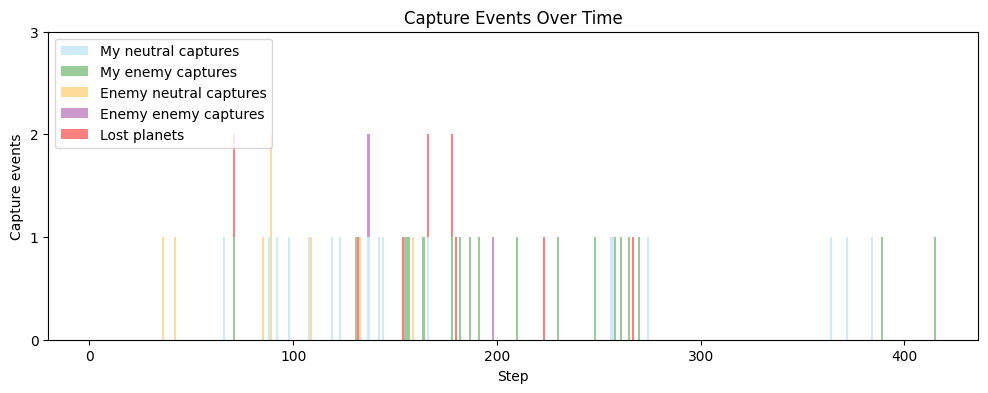

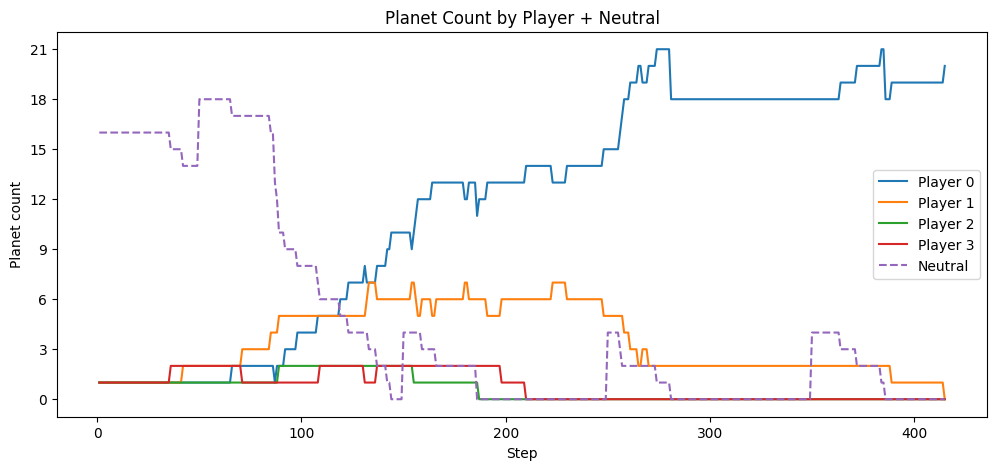

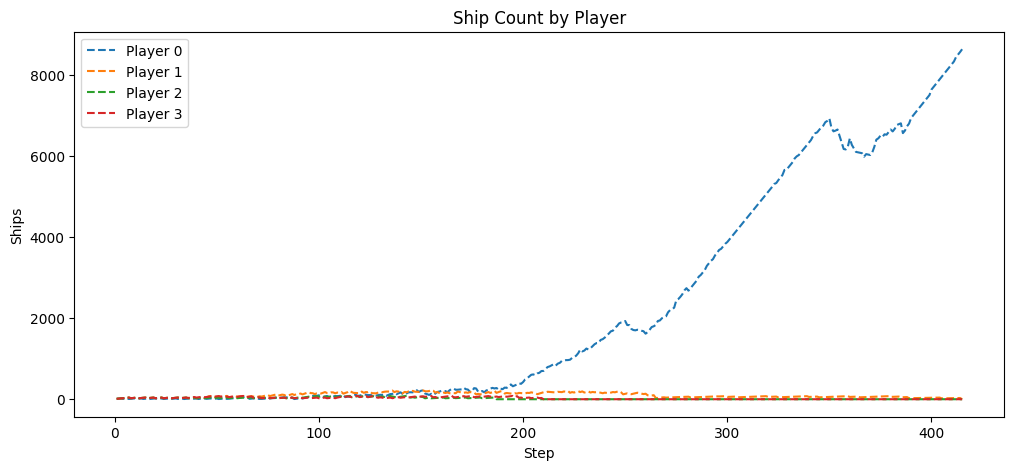

In [20]:
env = make("orbit_wars", debug=True, configuration={"seed": 42})
env.run([in_flight_agent, "random", "random", "random"])

plot_game_state(env)

In [15]:
# Sum ships on owned planets and fleets
def total_ships(obs, player_id):

    planets = obs["planets"]
    fleets = obs["fleets"]

    planet_ships = sum(p[5] for p in planets if p[1] == player_id)
    fleet_ships = sum(f[6] for f in fleets if f[1] == player_id)

    return planet_ships + fleet_ships
    
# Extract per-step game metrics for analysis    
def extract_game_timeseries(env, my_position):
    rows = []
    prev_owners = None

    # Iterate through each game step
    for step_idx in range(1, len(env.steps)):
        obs = env.steps[step_idx][my_position].observation
        player = obs.player
        planets = obs.planets

        # Current owner of each planet
        curr_owners = {p[0]: p[1] for p in planets}

        # Capture event counters for this step
        my_neutral_captures = 0
        my_enemy_captures = 0
        enemy_neutral_captures = 0
        enemy_enemy_captures = 0
        lost_planets = 0

        # Compare current owners with previous step owners
        if prev_owners is not None:
            for planet_id, curr_owner in curr_owners.items():
                prev_owner = prev_owners.get(planet_id)

                # Skip if ownership did not change
                if prev_owner is None or prev_owner == curr_owner:
                    continue

                # I captured a neutral planet
                if curr_owner == player and prev_owner == -1:
                    my_neutral_captures += 1

                # I captured an enemy planet
                elif curr_owner == player and prev_owner not in (-1, player):
                    my_enemy_captures += 1

                # I lost one of my planets
                elif prev_owner == player and curr_owner != player:
                    lost_planets += 1

                # An opponent captured a neutral planet
                elif prev_owner == -1 and curr_owner not in (-1, player):
                    enemy_neutral_captures += 1

                # One opponent captured another opponent's planet
                elif (
                    prev_owner not in (-1, player)
                    and curr_owner not in (-1, player)
                    and prev_owner != curr_owner
                ):
                    enemy_enemy_captures += 1

        # Basic planet counts
        my_planets = [p for p in planets if p[1] == player]
        neutral_planets = [p for p in planets if p[1] == -1]

        ships_by_player = {}
        planet_count_by_player = {}

        # Count ships and planets for each non-neutral player
        for p in planets:
            pid = p[1]
            if pid == -1:
                continue

            ships_by_player[pid] = ships_by_player.get(pid, 0) + p[5]
            planet_count_by_player[pid] = planet_count_by_player.get(pid, 0) + 1

        # Compare against the strongest opponent, not the average opponent
        enemy_players = [pid for pid in ships_by_player if pid != player]

        if enemy_players:
            best_enemy_ships = max(ships_by_player[pid] for pid in enemy_players)
            best_enemy_planets = max(planet_count_by_player[pid] for pid in enemy_players)
        else:
            best_enemy_ships = 0
            best_enemy_planets = 0

        # Store metrics for this step
        rows.append({
            "step": step_idx,

            "my_planets": len(my_planets),
            "best_enemy_planets": best_enemy_planets,
            "neutral_planets": len(neutral_planets),

            "my_ships": sum(p[5] for p in my_planets),
            "best_enemy_ships": best_enemy_ships,

            "my_neutral_captures": my_neutral_captures,
            "my_enemy_captures": my_enemy_captures,
            "enemy_neutral_captures": enemy_neutral_captures,
            "enemy_enemy_captures": enemy_enemy_captures,
            "lost_planets": lost_planets,
        })

        # Save current ownership for next-step comparison
        prev_owners = curr_owners

    return rows
    
# Plot average planets and ships over time (win vs loss)
def plot_average_game_state(timeseries_df):
    for result_label, flag in [("Winning Games", True), ("Losing Games", False)]:
        df_part = timeseries_df[timeseries_df["my_won"] == flag]

        if len(df_part) == 0:
            continue

        avg_df = df_part.groupby("step", as_index=False).mean(numeric_only=True)

        fig, ax1 = plt.subplots(figsize=(12, 5))

        ax1.plot(avg_df["step"], avg_df["my_planets"], label="My planets")
        ax1.plot(avg_df["step"], avg_df["best_enemy_planets"], label="Best opponent")
        ax1.plot(avg_df["step"], avg_df["neutral_planets"], label="Neutral")

        ax1.set_xlabel("Step")
        ax1.set_ylabel("Planet count")

        ax2 = ax1.twinx()
        ax2.plot(avg_df["step"], avg_df["my_ships"], linestyle="--", label="My ships")
        ax2.plot(avg_df["step"], avg_df["best_enemy_ships"], linestyle="--", label="Best opponent ships")

        ax2.set_ylabel("Ships")

        lines1, labels1 = ax1.get_legend_handles_labels()
        lines2, labels2 = ax2.get_legend_handles_labels()
        ax1.legend(lines1 + lines2, labels1 + labels2, loc="upper left")

        plt.title(f"Average Game State — {result_label} (Best Opponent)")
        plt.grid(True)
        plt.show()

# Print summary statistics and optionally plot ship margins
def summarize_results(results, plot=True):
    df = pd.DataFrame(results)

    n_games = len(df)

    wins = df["my_won"].sum()
    draws = (df["winner"] == -1).sum()
    losses = n_games - wins - draws

    print("games:", n_games)
    print("wins:", wins)
    print("losses:", losses)
    print("draws:", draws)
    print("win rate:", wins / n_games)
    print("avg rank:", df["my_rank"].mean())
    print("avg total ships:", df["my_total_ships"].mean())
    print("avg best other ships:", df["best_other_ships"].mean())
    print("avg ship margin vs best other:", df["ship_margin_vs_best_other"].mean())
    print("avg final turns:", df["final_turns"].mean())

    if plot:
        plt.figure(figsize=(8, 4))
        plt.bar(range(n_games), df["ship_margin_vs_best_other"])
        plt.axhline(0, linestyle="--")
        plt.xlabel("Game")
        plt.ylabel("Ship margin")
        plt.title("Ship Margin vs Best Opponent")
        plt.grid(True)
        plt.show()

    return df

# Visualize capture events over time (stacked bar)
def plot_average_capture_events(timeseries_df, step_range=None):
    df = timeseries_df.copy()

    if step_range is not None:
        start, end = step_range
        df = df[(df["step"] >= start) & (df["step"] <= end)]

    for result_label, flag in [("Winning Games", True), ("Losing Games", False)]:
        df_part = df[df["my_won"] == flag]

        if len(df_part) == 0:
            print(f"No {result_label.lower()} found.")
            continue

        avg_df = (
            df_part
            .groupby("step", as_index=False)
            .mean(numeric_only=True)
        )

        fig, ax = plt.subplots(figsize=(12, 4))

        bottom = np.zeros(len(avg_df))

        cols = [
            ("my_neutral_captures", "My neutral captures"),
            ("my_enemy_captures", "My enemy captures"),
            ("enemy_neutral_captures", "Enemy neutral captures"),
            ("enemy_enemy_captures", "Enemy enemy captures"),
            ("lost_planets", "Lost planets"),
        ]

        for col, label in cols:
            ax.bar(
                avg_df["step"],
                avg_df[col],
                bottom=bottom,
                alpha=0.4,
                width=1.0,
                label=label
            )
            bottom += avg_df[col].values

        ax.set_title(f"Average Capture Events — {result_label}")
        ax.set_xlabel("Step")
        ax.set_ylabel("Average capture events")
        ax.legend(loc="upper left")
        plt.show()

def evaluate_agents(agents, my_agent, seeds=range(20)):
    results = []
    timeseries_rows = []

    n_players = len(agents)

    if n_players not in [2, 4]:
        raise ValueError("Number of agents must be 2 or 4")

    for seed in seeds:
        lineup = list(agents)
        random.Random(seed).shuffle(lineup)

        my_position = lineup.index(my_agent)

        env = make(
            "orbit_wars",
            debug=False,
            configuration={"seed": seed}
        )
        env.run(lineup)

        final_states = env.steps[-1]
        final_turns = len(env.steps)

        total_ships_list = []

        for player_id in range(n_players):
            obs = final_states[player_id].observation
            total_ships_list.append(total_ships(obs, player_id))

        max_ships = max(total_ships_list)
        winners = [
            player_id
            for player_id, ships in enumerate(total_ships_list)
            if ships == max_ships
        ]

        winner = winners[0] if len(winners) == 1 else -1

        my_total = total_ships_list[my_position]
        best_other = max(
            ships
            for player_id, ships in enumerate(total_ships_list)
            if player_id != my_position
        )

        sorted_ships = sorted(total_ships_list, reverse=True)
        my_rank = sorted_ships.index(my_total) + 1
        my_won = winner == my_position

        result = {
            "seed": seed,
            "my_position": my_position,
            "my_won": my_won,
            "my_rank": my_rank,
            "winner": winner,
            "my_total_ships": my_total,
            "best_other_ships": best_other,
            "ship_margin_vs_best_other": my_total - best_other,
            "final_turns": final_turns,
        }

        for player_id, ships in enumerate(total_ships_list):
            result[f"total_ships_{player_id}"] = ships

        results.append(result)

        game_ts = extract_game_timeseries(env, my_position)

        for row in game_ts:
            row["seed"] = seed
            row["my_won"] = my_won
            row["my_rank"] = my_rank

        timeseries_rows.extend(game_ts)

    return pd.DataFrame(results), pd.DataFrame(timeseries_rows)
    

In [16]:
results_2p, ts_2p = evaluate_agents(
    agents=[in_flight_agent, "random"],
    my_agent=in_flight_agent,
    seeds=range(20)
)

df_2p = summarize_results(results_2p)
plot_average_game_state(ts_2p)
plot_average_capture_events(ts_2p, step_range=(0, 200))

NameError: name 'in_flight_agent' is not defined